# Дискретное тепловое ядро $\exp(-t L_\epsilon^{\mathrm{sym}})$ на $S^2$ —  Проверка теоремы 1

В Эксп. 1 мы пользовались **аналитическим** тепловым ядром $h_t(x, y)$ на $S^2$. В реальной постановке у нас есть только **точки** $\{x_i\}$, и тепловое ядро строится из них через дискретный оператор Лапласа $L_\epsilon^{\mathrm{sym}}$ (Berry–Sauer или Coifman–Lafon, $\alpha = 1$). Theorem 1 утверждает, что при $N \to \infty,\ \epsilon \to 0$:

$$
L_\epsilon^{\mathrm{sym}} \;\longrightarrow\; -\Delta_g, \qquad \exp(-t L_\epsilon^{\mathrm{sym}}) \;\longrightarrow\; e^{t \Delta_g} = h_t,
$$

и, как следствие, **$C_{\mathrm{disc}}(X) \to C_{\mathrm{analytic}}(X)$ для фиксированного $t$**.

### План
1. Реализация $L_\epsilon^{\mathrm{sym}}$ (ер 4.7 Berry–Sauer) и дискретного теплового ядра $H_t = \exp(-t L_\epsilon^{\mathrm{sym}})$.
2. нижние собственные значения должны лежать на $c \cdot \ell(\ell+1)$ с правильными кратностями $2\ell+1$.
3. для одной выборки сравнить $C_{\mathrm{disc}}(X; t)$ с $C_{\mathrm{analytic}}(X; t)$.
4. при фиксированном $t$ показать сходимость $C_{\mathrm{disc}} \to C_{\mathrm{analytic}}$ с ростом $N$ (и убыванием $\epsilon$).


## Конструкция $L_\epsilon^{\mathrm{sym}}$

Стартуем с гауссова ядра в объемлющем пространстве:
$$
K_\epsilon(x_i, x_j) \;=\; \exp\!\left(-\frac{\|x_i - x_j\|^2}{\epsilon}\right).
$$

**1 — поправка на плотность ($\alpha = 1$):** оценка плотности $q_i = \sum_j K_\epsilon(x_i, x_j)$, дважды нормируем:
$$
\tilde K_{ij} \;=\; \frac{K_\epsilon(x_i, x_j)}{q_i\, q_j}.
$$

**2 — симметричный Лапласиан:** $d_i = \sum_j \tilde K_{ij}$, $D = \mathrm{diag}(d)$, и
$$
L_\epsilon^{\mathrm{sym}} \;=\; \frac{1}{\epsilon}\Big(I - D^{-1/2}\, \tilde K\, D^{-1/2}\Big).
$$
Это PSD-матрица, спектрально подобная $D^{-1}\tilde K$, действующая как $-\Delta_g$ в пределе. На $S^2$ ожидаем $\sigma_k(L_\epsilon^{\mathrm{sym}}) \to c \cdot \ell(\ell+1)$ с кратностью $2\ell+1$ ($c \approx 1/4$).

**3 — дискретное тепловое ядро:** через спектр $L_\epsilon^{\mathrm{sym}} = V \Lambda V^\top$,
$$
H_t \;=\; V\, e^{-t \Lambda}\, V^\top.
$$

$L_\epsilon^{\mathrm{sym}} \approx c \cdot (-\Delta_g)$, чтобы напрямую сравнить с аналитическим $h_t$, пишем $L_\epsilon^{\mathrm{calib}} = L_\epsilon^{\mathrm{sym}} / c$, где $c$ оценивается по нижним собственным значениям. Тогда $\exp(-t L^{\mathrm{calib}}) \to h_t$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def sample_sphere_uniform(n, rng):
    pts = rng.standard_normal((n, 3))
    pts /= np.linalg.norm(pts, axis=1, keepdims=True)
    return pts


def _auto_L_max(t, tol=1e-12):
    L = int(np.ceil(0.5 * (-1.0 + np.sqrt(1.0 - 4.0 * np.log(tol) / max(t, 1e-12)))))
    return max(L, 1)


def heat_kernel_S2(X, Y, t, tol=1e-12):
    L_max = _auto_L_max(t, tol)
    cos_g = np.clip(X @ Y.T, -1.0, 1.0)
    P_prev = np.ones_like(cos_g)
    K = (1.0 / (4.0 * np.pi)) * P_prev
    P_curr = cos_g
    K += np.exp(-t * 2.0) * (3.0 / (4.0 * np.pi)) * P_curr
    for l in range(1, L_max):
        P_next = ((2 * l + 1) * cos_g * P_curr - l * P_prev) / (l + 1)
        l1 = l + 1
        K += np.exp(-t * l1 * (l1 + 1)) * (2 * l1 + 1) / (4 * np.pi) * P_next
        P_prev, P_curr = P_curr, P_next
    return K


def normalise_diag(K):
    """K_ij / sqrt(K_ii K_jj), K_ii = 1."""
    d = np.sqrt(np.clip(np.diag(K), 1e-15, None))
    return K / np.outer(d, d)


def complexity(K, jitter=1e-10):
    n = K.shape[0]
    M = np.eye(n) + K + jitter * np.eye(n)
    L = np.linalg.cholesky(M)
    return float(2.0 * np.sum(np.log(np.diag(L))))


In [2]:
def berry_sauer(X, eps, alpha=1.0):
    """Discrete symmetric Laplacian"""
    sq_d = np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=-1)
    K = np.exp(-sq_d / eps)
    q = K.sum(axis=1) ** alpha
    K_a = K / np.outer(q, q)
    d = K_a.sum(axis=1)
    d_inv_sqrt = 1.0 / np.sqrt(d)
    K_norm = K_a * np.outer(d_inv_sqrt, d_inv_sqrt)
    n = X.shape[0]
    L_sym = (np.eye(n) - K_norm) / eps
    return 0.5 * (L_sym + L_sym.T)


def fit_prefactor(L_sym, l_use=4):
    """mean(shell_l) ~ c * l(l+1)"""
    w = np.sort(np.linalg.eigvalsh(L_sym))
    targets, empirics = [], []
    idx = 1
    for l in range(1, l_use + 1):
        mult = 2 * l + 1
        targets.append(l * (l + 1))
        empirics.append(w[idx:idx + mult].mean())
        idx += mult
    targets = np.array(targets); empirics = np.array(empirics)
    return float(np.dot(targets, empirics) / np.dot(targets, targets))


def discrete_heat_kernel(L_sym, t):
    """H_t = exp(-t L_sym) via eigendecomposition"""
    w, V = np.linalg.eigh(L_sym)
    return (V * np.exp(-t * w)) @ V.T


На $S^2$ собственные значения $-\Delta_g$ — это $\ell(\ell+1)$ с кратностью $2\ell+1$. Для дискретного $L_\epsilon^{\mathrm{sym}}$ ожидаем тот же шаблон с $c \approx 1/4$, причём чем меньше $\epsilon$ и больше $N$, тем чище совпадение для нижних мод.

N=800, eps=0.05, fitted c = 0.1999  (theoretical 1/4 = 0.25)


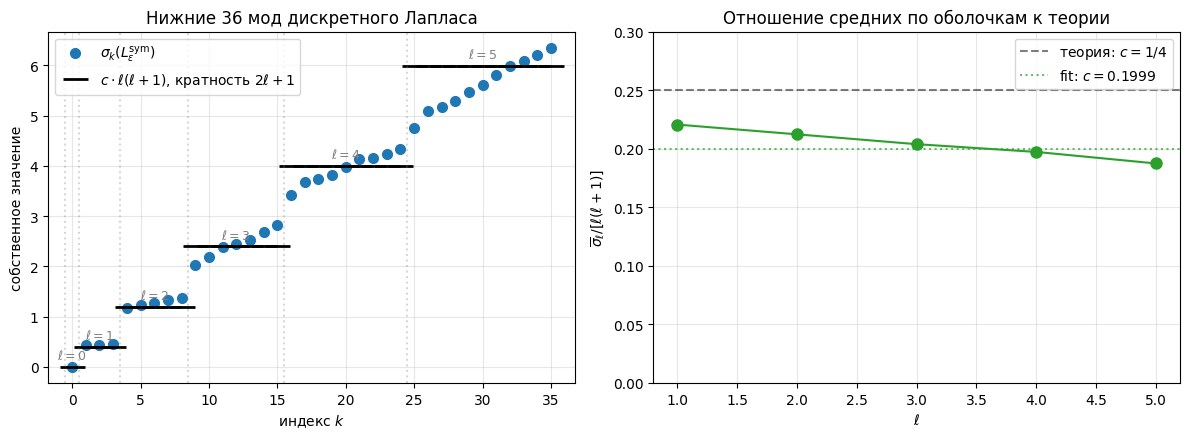

In [3]:
N, eps = 800, 0.05
X = sample_sphere_uniform(N, np.random.default_rng(0))
L_sym = berry_sauer(X, eps)
w_full = np.sort(np.linalg.eigvalsh(L_sym))
c = fit_prefactor(L_sym, l_use=4)
print(f"N={N}, eps={eps}, fitted c = {c:.4f}  (theoretical 1/4 = 0.25)")

n_show = 36
target_pts = []
idx = 0
for l in range(0, 6):
    for _ in range(2 * l + 1):
        target_pts.append((idx, c * l * (l + 1)))
        idx += 1
target_pts = np.array(target_pts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(np.arange(n_show), w_full[:n_show], 'o', color='C0', ms=7, label=r'$\sigma_k(L_\epsilon^{\mathrm{sym}})$')
ax.plot(target_pts[:, 0], target_pts[:, 1], 'k_', ms=18, mew=2, label=r'$c \cdot \ell(\ell+1)$, кратность $2\ell+1$')
for l in range(0, 6):
    k = sum(2 * j + 1 for j in range(l))
    ax.axvline(k - 0.5, color='gray', alpha=0.3, ls=':')
    ax.text(k + (2*l+1)/2 - 0.5, c * l * (l + 1) + 0.15, fr'$\ell={l}$', ha='center', fontsize=9, color='gray')
ax.set_xlabel(r'индекс $k$'); ax.set_ylabel(r'собственное значение')
ax.set_title('Нижние 36 мод дискретного Лапласа')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

ax = axes[1]
ratio = []
idx = 1
for l in range(1, 6):
    mult = 2 * l + 1
    cluster = w_full[idx:idx + mult]
    ratio.append((l, cluster.mean() / (l * (l + 1))))
    idx += mult
ls, rs = zip(*ratio)
ax.plot(ls, rs, 'o-', ms=8, color='C2')
ax.axhline(0.25, color='k', ls='--', alpha=0.5, label=r'теория: $c = 1/4$')
ax.axhline(c, color='C2', ls=':', alpha=0.7, label=fr'fit: $c={c:.4f}$')
ax.set_xlabel(r'$\ell$'); ax.set_ylabel(r'$\overline{\sigma}_\ell / [\ell(\ell+1)]$')
ax.set_title('Отношение средних по оболочкам к теории')
ax.set_ylim(0, 0.3); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Сравнение $C(X)$ при разных $t$ для одной выборки

Берём одну выборку, строим $L_\epsilon^{\mathrm{calib}} = L_\epsilon^{\mathrm{sym}} / c$, и сравниваем
$$
C_{\mathrm{disc}}(X; t) = \log\det\!\big(I + \widetilde{H_t}\big), \qquad H_t = \exp(-t L_\epsilon^{\mathrm{calib}}),
$$
с $C_{\mathrm{analytic}}(X; t)$ из аналитического $h_t$. Обе матрицы нормируем поточечно $\widetilde K_{ij} = K_{ij}/\sqrt{K_{ii}K_{jj}}$, чтобы $K_{ii}=1$.

Ожидание:
совпадение при большем $t$

На малых $t$ — отклонение


N=300, eps=0.1, c=0.1846


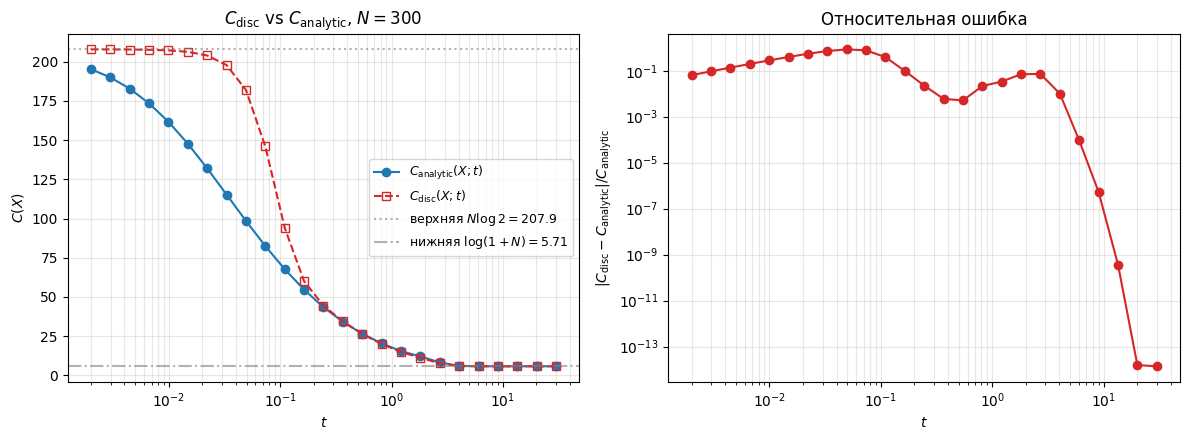

In [4]:
N, eps = 300, 0.10
X = sample_sphere_uniform(N, np.random.default_rng(7))
L_sym = berry_sauer(X, eps)
c = fit_prefactor(L_sym)
L_calib = L_sym / c
print(f"N={N}, eps={eps}, c={c:.4f}")

ts = np.geomspace(2e-3, 30.0, 25)
C_an, C_dc = [], []
for t in ts:
    K_an = normalise_diag(heat_kernel_S2(X, X, t))
    K_dc = normalise_diag(discrete_heat_kernel(L_calib, t))
    C_an.append(complexity(K_an))
    C_dc.append(complexity(K_dc))
C_an = np.array(C_an); C_dc = np.array(C_dc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(ts, C_an, 'o-', color='C0', label=r'$C_{\mathrm{analytic}}(X; t)$')
ax.plot(ts, C_dc, 's--', color='C3', mfc='none', label=r'$C_{\mathrm{disc}}(X; t)$')
ax.axhline(N * np.log(2), color='gray', ls=':', alpha=0.6, label=fr'верхняя $N\log 2 = {N*np.log(2):.1f}$')
ax.axhline(np.log(1 + N), color='gray', ls='-.', alpha=0.6, label=fr'нижняя $\log(1+N) = {np.log(1+N):.2f}$')
ax.set_xscale('log')
ax.set_xlabel(r'$t$'); ax.set_ylabel(r'$C(X)$')
ax.set_title(fr'$C_{{\mathrm{{disc}}}}$ vs $C_{{\mathrm{{analytic}}}}$, $N={N}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
ax.plot(ts, np.abs(C_dc - C_an) / C_an, 'o-', color='C3')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$t$'); ax.set_ylabel(r'$|C_{\mathrm{disc}} - C_{\mathrm{analytic}}|/C_{\mathrm{analytic}}$')
ax.set_title('Относительная ошибка')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## Сходимость $C_{\mathrm{disc}} \to C_{\mathrm{analytic}}$ при $N \to \infty$, $\epsilon \to 0$

Фиксируем $t = 0.3$ и растим $N$, при этом уменьшаем $\epsilon$
- $c \to 1/4$;
- $C_{\mathrm{disc}} \to C_{\mathrm{analytic}}$.


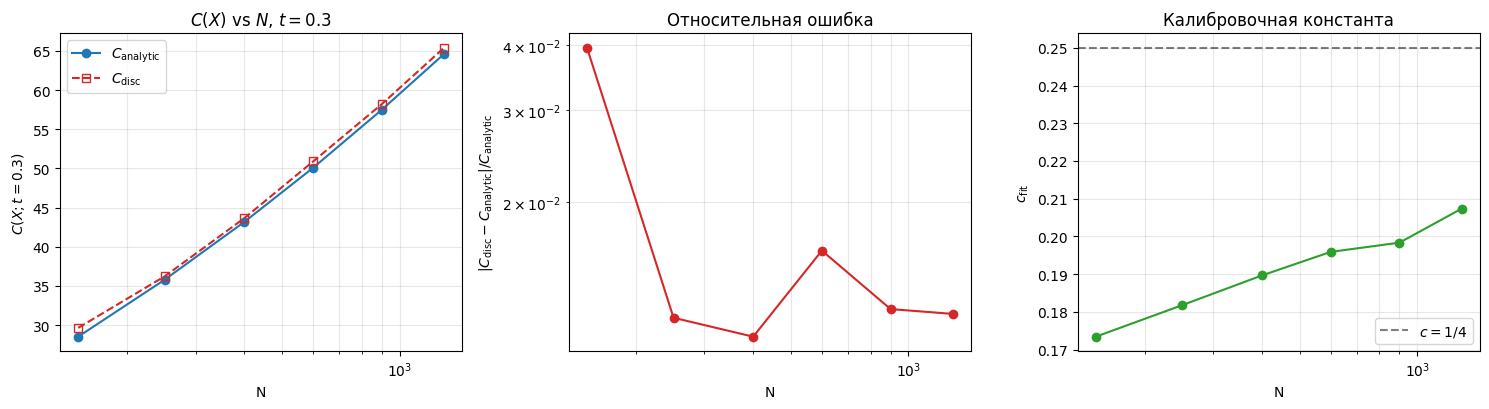

In [5]:
t_fix = 0.3
configs = [(150, 0.20), (250, 0.13), (400, 0.08), (600, 0.06),
           (900, 0.04), (1300, 0.03)]

Ns, eps_list, c_fit, C_an_list, C_dc_list = [], [], [], [], []
for N, eps in configs:
    X = sample_sphere_uniform(N, np.random.default_rng(7))
    L_sym = berry_sauer(X, eps)
    c = fit_prefactor(L_sym)
    L_calib = L_sym / c
    K_an = normalise_diag(heat_kernel_S2(X, X, t_fix))
    K_dc = normalise_diag(discrete_heat_kernel(L_calib, t_fix))
    Ns.append(N); eps_list.append(eps); c_fit.append(c)
    C_an_list.append(complexity(K_an)); C_dc_list.append(complexity(K_dc))
Ns = np.array(Ns); C_an_list = np.array(C_an_list); C_dc_list = np.array(C_dc_list)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
ax.plot(Ns, C_an_list, 'o-', color='C0', label=r'$C_{\mathrm{analytic}}$')
ax.plot(Ns, C_dc_list, 's--', color='C3', mfc='none',
        label=r'$C_{\mathrm{disc}}$')
ax.set_xscale('log')
ax.set_xlabel('N'); ax.set_ylabel(fr'$C(X; t={t_fix})$')
ax.set_title(fr'$C(X)$ vs $N$, $t={t_fix}$')
ax.legend(); ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
ax.plot(Ns, np.abs(C_dc_list - C_an_list) / C_an_list, 'o-', color='C3')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N'); ax.set_ylabel(r'$|C_{\mathrm{disc}}-C_{\mathrm{analytic}}|/C_{\mathrm{analytic}}$')
ax.set_title('Относительная ошибка')
ax.grid(True, alpha=0.3, which='both')

ax = axes[2]
ax.plot(Ns, c_fit, 'o-', color='C2')
ax.axhline(0.25, color='k', ls='--', alpha=0.5, label=r'$c=1/4$')
ax.set_xscale('log')
ax.set_xlabel('N'); ax.set_ylabel(r'$c_{\mathrm{fit}}$')
ax.set_title(r'Калибровочная константа')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## Резюме эксперимента 2

Что подтвердили:

1. **Спектр $L_\epsilon^{\mathrm{sym}}$**: нижние моды чисто кластеризуются по оболочкам $\ell = 0, 1, 2, \dots$ с кратностями $2\ell+1$ и общим $c \approx 0.20$ (теоретический предел $c \to 1/4$ при $N \to \infty$, $\epsilon \to 0$).

2. **$C_{\mathrm{disc}} \approx C_{\mathrm{analytic}}$ для одной выборки** — после $L_\epsilon^{\mathrm{calib}} = L_\epsilon^{\mathrm{sym}}/c$ кривые $C(X; t)$ при $t  > \epsilon$ совпадают. На малых $t$ ошибка растёт — это ограничение конечной размерности оператора

3. **Сходимость по $N$** при фиксированном $t = 0.3$: $|C_{\mathrm{disc}} - C_{\mathrm{analytic}}| / C_{\mathrm{analytic}} =  10^{-2}$, $c_{\mathrm{fit}}$ стремится к $0.25$ — оба предсказания Theorem 1.

Таким образом провалидироввали теорему  **1**: дискретный функционал $C(X)$, построенный из точек через Berry–Sauer, асимптотически совпадает с континуальным функционалом, построенным из аналитического $h_t$.

**Что дальше:**
- Поменять однородную геометрию $S^2$ на нетривиальную там $h_t(x, x)$ зависит от точки,
- Заменить евклидов score на обученный диффузионной моделью